# 实验三：空间域图像滤波（平滑与锐化）

**实验目的：**
理解空间域卷积操作的原理，掌握常用的线性与非线性空间滤波器。

**实验准备：**
请确保在当前目录下有一张名为 `lena.jpg` 的图像。


图像读取成功！尺寸: (240, 320)


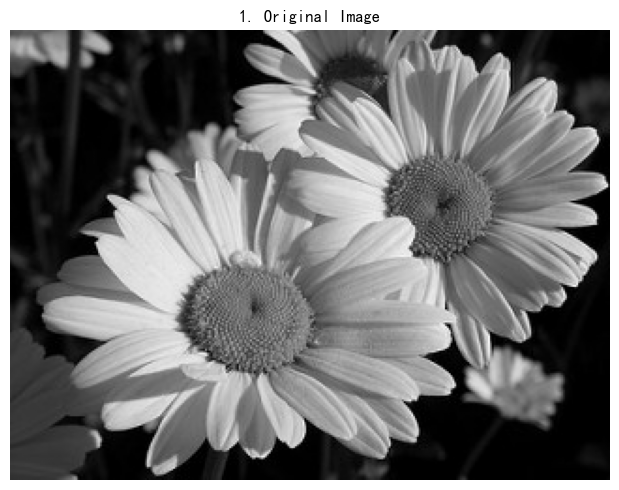

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 使得 Matplotlib 图像直接嵌在 Notebook 中显示
%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def show_images(images, titles, figsize=(15, 5)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 读取原始图像并转为灰度图
img = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("⚠️ 找不到 lena.jpg，请准备一张图片并重命名为 lena.jpg！")
else:
    print(f"图像读取成功！尺寸: {img.shape}")
    show_images([img], ["1. Original Image"])


## 1. 为图像添加噪声
在现实生活中，传感器发热会产生高斯噪声，而信号传输错误会产生椒盐噪声。


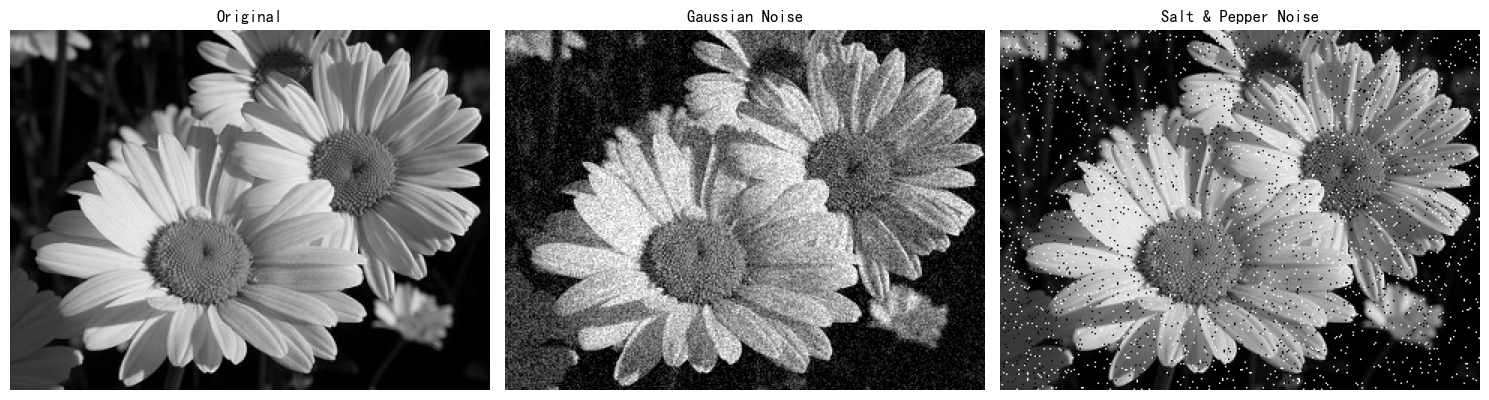

In [2]:
def add_gaussian_noise(image, mean=0, sigma=25):
    gauss = np.random.normal(mean, sigma, image.shape)
    noisy_img = np.clip(image.astype(np.float32) + gauss, 0, 255)
    return noisy_img.astype(np.uint8)

def add_salt_and_pepper_noise(image, ratio=0.05):
    noisy_img = np.copy(image)
    h, w = noisy_img.shape
    num_noise = int(h * w * ratio)

    # 添加白点和黑点
    for _ in range(num_noise // 2):
        noisy_img[np.random.randint(0, h), np.random.randint(0, w)] = 255
        noisy_img[np.random.randint(0, h), np.random.randint(0, w)] = 0
    return noisy_img

if img is not None:
    img_gaussian = add_gaussian_noise(img)
    img_sp = add_salt_and_pepper_noise(img)
    show_images([img, img_gaussian, img_sp], 
                ["Original", "Gaussian Noise", "Salt & Pepper Noise"])


## 2. 平滑处理（均值滤波 vs 中值滤波）
**对比重点：** 观察均值滤波对边缘的模糊程度，以及中值滤波去除椒盐噪声的奇效。


🔽 高斯噪声平滑对比：


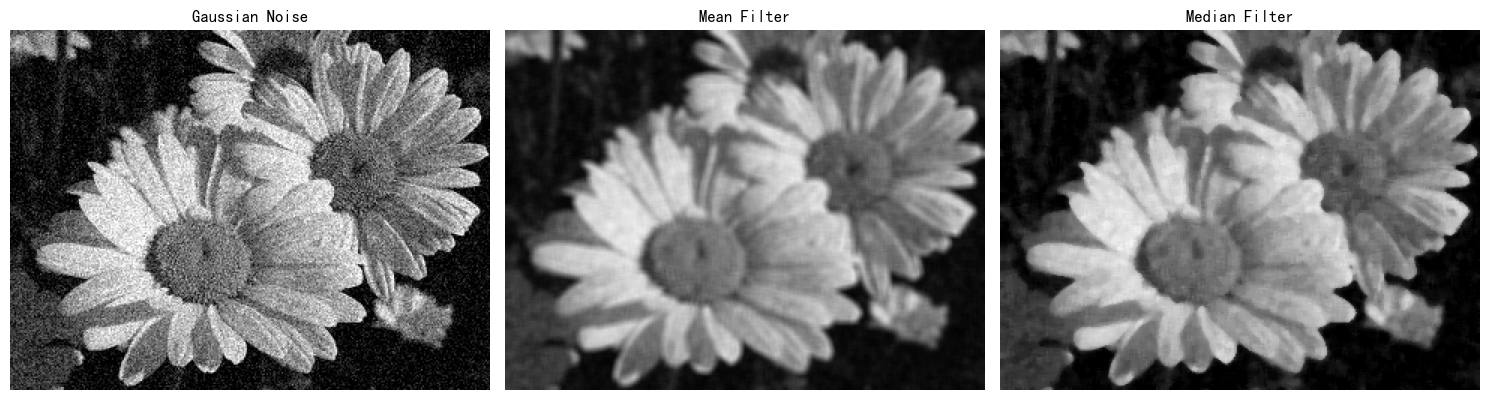

🔽 椒盐噪声平滑对比 (中值滤波完胜)：


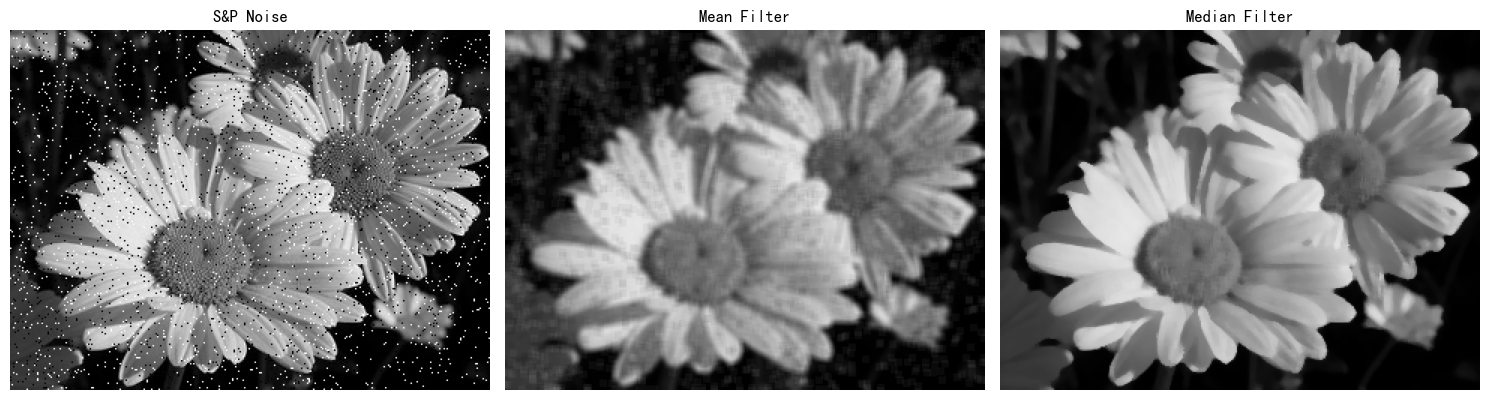

In [3]:
if img is not None:
    # --- 处理高斯噪声 ---
    blur_mean_gaussian = cv2.blur(img_gaussian, (5, 5))
    blur_median_gaussian = cv2.medianBlur(img_gaussian, 5)

    print("🔽 高斯噪声平滑对比：")
    show_images([img_gaussian, blur_mean_gaussian, blur_median_gaussian], 
                ["Gaussian Noise", "Mean Filter", "Median Filter"])

    # --- 处理椒盐噪声 ---
    blur_mean_sp = cv2.blur(img_sp, (5, 5))
    blur_median_sp = cv2.medianBlur(img_sp, 5)

    print("🔽 椒盐噪声平滑对比 (中值滤波完胜)：")
    show_images([img_sp, blur_mean_sp, blur_median_sp], 
                ["S&P Noise", "Mean Filter", "Median Filter"])


## 3. 锐化处理（Laplacian 算子）
通过计算二阶导数寻找灰度变化剧烈的边缘，然后加回原图实现锐化。


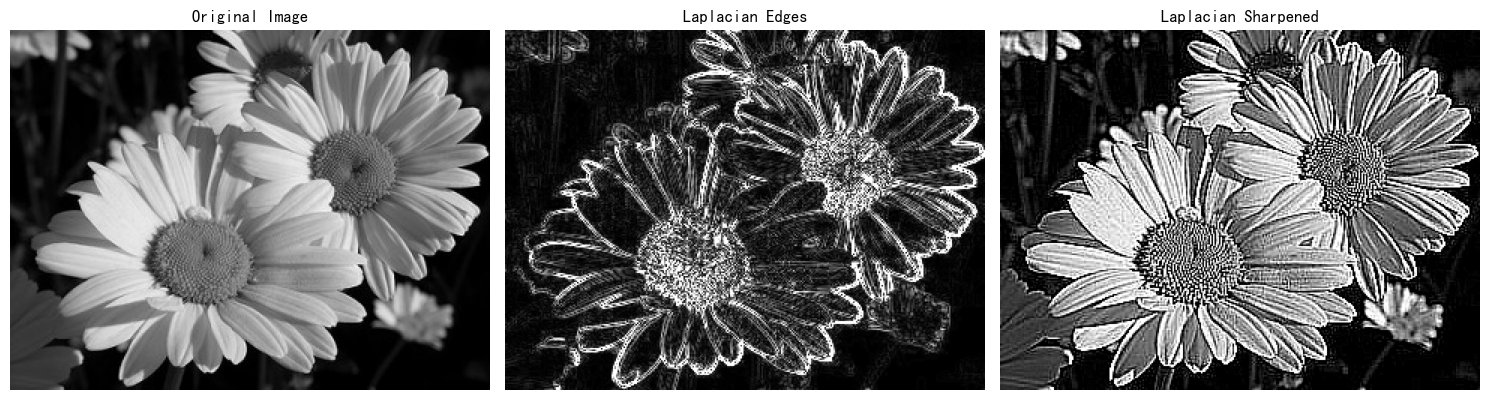

In [4]:
if img is not None:
    # 计算拉普拉斯边缘 (必须用 64 位浮点数存储以保留负数)
    laplacian = cv2.Laplacian(img, cv2.CV_64F, ksize=3)
    laplacian_show = cv2.convertScaleAbs(laplacian)

    # 图像锐化增强: 原图 - 边缘 (因为 OpenCV 默认核中心权重为负)
    img_sharpened = np.clip(img.astype(np.float32) - laplacian, 0, 255).astype(np.uint8)

    show_images([img, laplacian_show, img_sharpened], 
                ["Original Image", "Laplacian Edges", "Laplacian Sharpened"])


## 4. 非锐化掩蔽（Unsharp Masking）
核心思路：提取原图与模糊图的差值（高频细节），再将这些细节放大后加回原图。


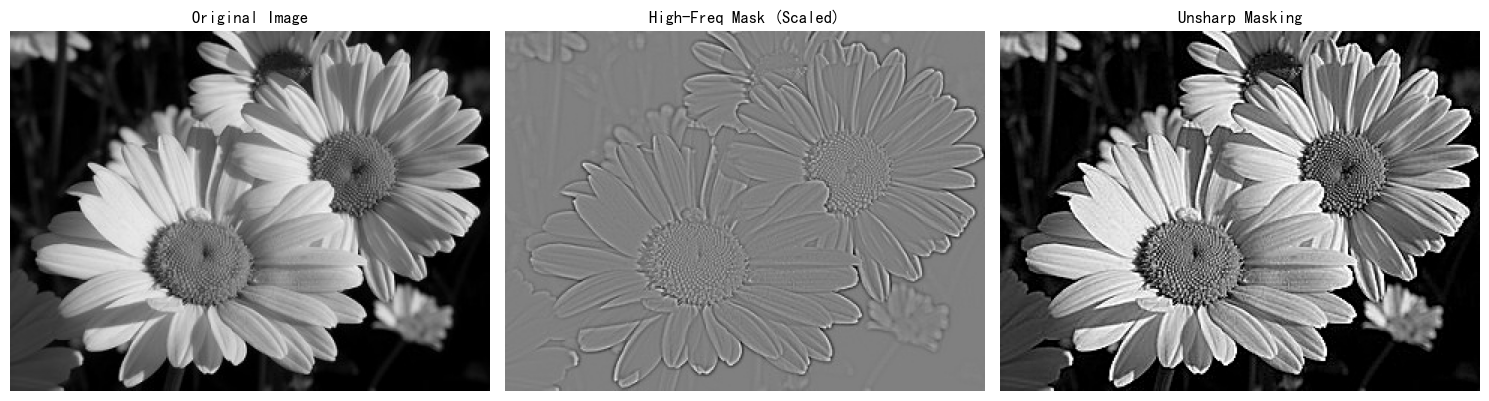

In [5]:
if img is not None:
    # 1. 高斯平滑
    blurred_for_unsharp = cv2.GaussianBlur(img, (5, 5), 2.0)

    # 2. 提取掩蔽 (Mask)
    mask = img.astype(np.float32) - blurred_for_unsharp.astype(np.float32)
    mask_show = np.clip(mask + 128, 0, 255).astype(np.uint8) # 偏移到 128 方便显示

    # 3. 加回原图 (设定强度 k=1.5)
    k = 1.5
    unsharp_img = np.clip(img.astype(np.float32) + k * mask, 0, 255).astype(np.uint8)

    show_images([img, mask_show, unsharp_img], 
                ["Original Image", "High-Freq Mask (Scaled)", "Unsharp Masking"])
